# 📊 Phần 2: Ứng Dụng Dữ Liệu Thực Tế - Dự Đoán Mức Lương NBA

Notebook này thực hiện toàn bộ quy trình từ Khảo sát dữ liệu (EDA), Tiền xử lý dữ liệu hướng đối tượng (OOP Data Pipeline), Huấn luyện & so sánh các mô hình hồi quy (OLS, OLS chọn biến, Ridge, Lasso, Bayesian Linear Regression) và trực quan hóa kết quả.

## 0. **Chuẩn bị thư viện và đọc file**
Import các thư viện sau trước khi chạy các cell dưới 

In [1]:
import sys
import os
import math
sys.path.append(os.path.abspath(os.path.join(os.getcwd())))
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from part1.ols_implementation import ols_fit
from part1.residual_analysis import residual_plots
import part1.helper_function as hf
warnings.filterwarnings('ignore')

print('Đã import thành công!')

Đã import thành công!


Đọc file cần xử lý dữ liệu

In [2]:
data_path = 'part2/data/nba_salary_raw.csv' # Dán đường dẫn của file vào đây
if not os.path.exists(data_path):
    data_path = 'part2/data/nba_salaries.csv' # Đường dẫn phụ nếu đường dẫn chính không hoạt động
df = pd.read_csv(data_path)

## **1. Khảo sát dữ liệu (Exploratory Data Analysis - EDA)**

Chúng ta sẽ đọc dữ liệu từ file .csv và thực hiện EDA cho dữ liệu
### 1.1. Kích thước và thống kê dữ liệu

Xem xét xem dữ liệu có bao nhiêu quan trắc, bao nhiêu thuộc tính

In [3]:
print(f'📊 Kích thước dữ liệu: {df.shape[0]} dòng, {df.shape[1]} cột')

📊 Kích thước dữ liệu: 467 dòng, 52 cột


Thống kê kiểu dữ liệu của từng cột

In [4]:
dtype_df = pd.DataFrame({
    'Đặc trưng (Cột)': df.columns,
    'Kiểu dữ liệu (Dtype)': df.dtypes.astype(str).values
})

dtype_df['Nhóm biến'] = dtype_df['Kiểu dữ liệu (Dtype)'].apply(
    lambda x: 'Số(Numeric)' if 'int' in x or 'float' in x else 'Chuỗi/Phân loại (Object)'
)

with pd.option_context('display.max_rows', None):
    display(dtype_df)

print("\n" + "="*60)
print("THỐNG KÊ SỐ LƯỢNG CỘT THEO TỪNG KIỂU DỮ LIỆU")
print("="*60)

summary_df = df.dtypes.value_counts().reset_index()
summary_df.columns = ['Kiểu dữ liệu', 'Số lượng cột']
display(summary_df)

,Đặc trưng (Cột),Kiểu dữ liệu (Dtype),Nhóm biến
0,Unnamed: 0,int64,Số(Numeric)
1,Player Name,object,Chuỗi/Phân loại (Object)
2,Salary,int64,Số(Numeric)
3,Position,object,Chuỗi/Phân loại (Object)
4,Age,int64,Số(Numeric)
5,Team,object,Chuỗi/Phân loại (Object)
6,GP,int64,Số(Numeric)
7,GS,int64,Số(Numeric)
8,MP,float64,Số(Numeric)
9,FG,float64,Số(Numeric)



THỐNG KÊ SỐ LƯỢNG CỘT THEO TỪNG KIỂU DỮ LIỆU


,Kiểu dữ liệu,Số lượng cột
0,float64,43
1,int64,6
2,object,3


Kiểm tra dữ liệu trùng lặp

In [5]:
num_duplicates = df.duplicated().sum()
print(f"Số dòng bị trùng lặp: {num_duplicates} dòng")

if num_duplicates > 0:
    print("Xóa các dòng trùng lặp...")
    # Xóa dòng trùng, giữ lại dòng xuất hiện đầu tiên
    df = df.drop_duplicates(keep='first')
    print(f"=> Kích thước dữ liệu sau khi làm sạch: {df.shape[0]} dòng, {df.shape[1]} cột")
else:
    print("=> Dữ liệu sạch, không có dòng trùng lặp.")

Số dòng bị trùng lặp: 0 dòng
=> Dữ liệu sạch, không có dòng trùng lặp.


Xem xét các đại lượng thống kê cơ bản: mean, median, std, min, max, quartiles (25%, 50%, 75%).

In [6]:
df = df.drop(columns=['Unnamed: 0'], errors='ignore')

display(df.describe())

,Salary,Age,GP,GS,MP,FG,FGA,FG%,3P,3PA,...,TOV%,USG%,OWS,DWS,WS,WS/48,OBPM,DBPM,BPM,VORP
count,4.670000e+02,467.000000,467.000000,467.000000,467.000000,467.000000,467.000000,466.000000,467.000000,467.000000,...,467.000000,467.000000,467.000000,467.000000,467.000000,467.000000,467.000000,467.000000,467.000000,467.000000
mean,8.416599e+06,25.820128,48.233405,22.650964,19.871306,3.351392,7.117773,0.465009,0.996574,2.792719,...,12.735974,18.425910,1.208351,1.120557,2.328908,0.081771,-1.344968,-0.087152,-1.432548,0.539829
std,1.070812e+07,4.275113,24.807740,27.094577,9.548684,2.457836,5.020700,0.109547,0.880468,2.260794,...,7.198533,5.909528,1.765160,0.980478,2.533094,0.088089,3.578193,2.243437,4.925175,1.172960
min,5.849000e+03,19.000000,1.000000,0.000000,1.800000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,5.100000,-1.900000,0.000000,-1.600000,-0.517000,-22.500000,-10.400000,-26.500000,-1.300000
25%,1.782621e+06,23.000000,31.000000,1.000000,12.500000,1.600000,3.300000,0.417000,0.300000,1.000000,...,9.500000,14.300000,0.000000,0.300000,0.300000,0.047000,-2.900000,-0.900000,-3.300000,-0.100000
50%,3.722040e+06,25.000000,55.000000,8.000000,19.200000,2.700000,5.800000,0.455000,0.800000,2.400000,...,11.900000,17.600000,0.600000,0.900000,1.500000,0.087000,-1.300000,-0.100000,-1.300000,0.100000
75%,1.063354e+07,29.000000,68.500000,45.500000,28.300000,4.300000,9.400000,0.507500,1.500000,4.150000,...,15.000000,21.150000,1.800000,1.800000,3.550000,0.129500,0.450000,0.800000,0.600000,0.800000
max,4.807001e+07,42.000000,83.000000,83.000000,41.000000,11.200000,22.200000,1.000000,4.900000,11.400000,...,100.000000,52.500000,9.600000,4.800000,12.600000,0.626000,17.000000,32.700000,48.600000,6.400000


Phân tích missing values trên bộ dữ liệu

In [7]:
# Tính toán số lượng và tỷ lệ % khuyết
missing_counts = df.isnull().sum()
missing_pct = (missing_counts / len(df)) * 100

# Gom thành DataFrame và chỉ lọc ra những cột có dữ liệu khuyết
missing_df = pd.DataFrame({
    'Số lượng khuyết': missing_counts,
    'Tỷ lệ khuyết': missing_pct
})
missing_df = missing_df[missing_df['Số lượng khuyết'] > 0].sort_values(by='Tỷ lệ khuyết', ascending=False)

if missing_df.empty:
    print("Bộ dữ liệu không có giá trị khuyết nào.")
else:
    print(f"Phát hiện {len(missing_df)} cột có chứa giá trị khuyết (Missing Values):")
    # Hiển thị bảng đẹp trong Jupyter Notebook
    display(missing_df.style.format({'Tỷ lệ khuyết (%)': "{:.2f}%"}).background_gradient(cmap='Reds'))

Phát hiện 8 cột có chứa giá trị khuyết (Missing Values):


,Số lượng khuyết,Tỷ lệ khuyết
FT%,23,4.925054
3P%,13,2.783726
2P%,4,0.856531
FG%,1,0.214133
eFG%,1,0.214133
TS%,1,0.214133
3PAr,1,0.214133
FTr,1,0.214133


### 1.2. Phân phối từng biến & Boxplot (Phát hiện Outliers)
Sử dụng Histogram để xem phân phối và Boxplot để kiểm tra các điểm dị biệt (Outliers) dựa trên khoảng phân vị (IQR).

### a. Trực quan hóa dữ liệu bằng Histogram

- Đối với biến mục tiêu (Salary)

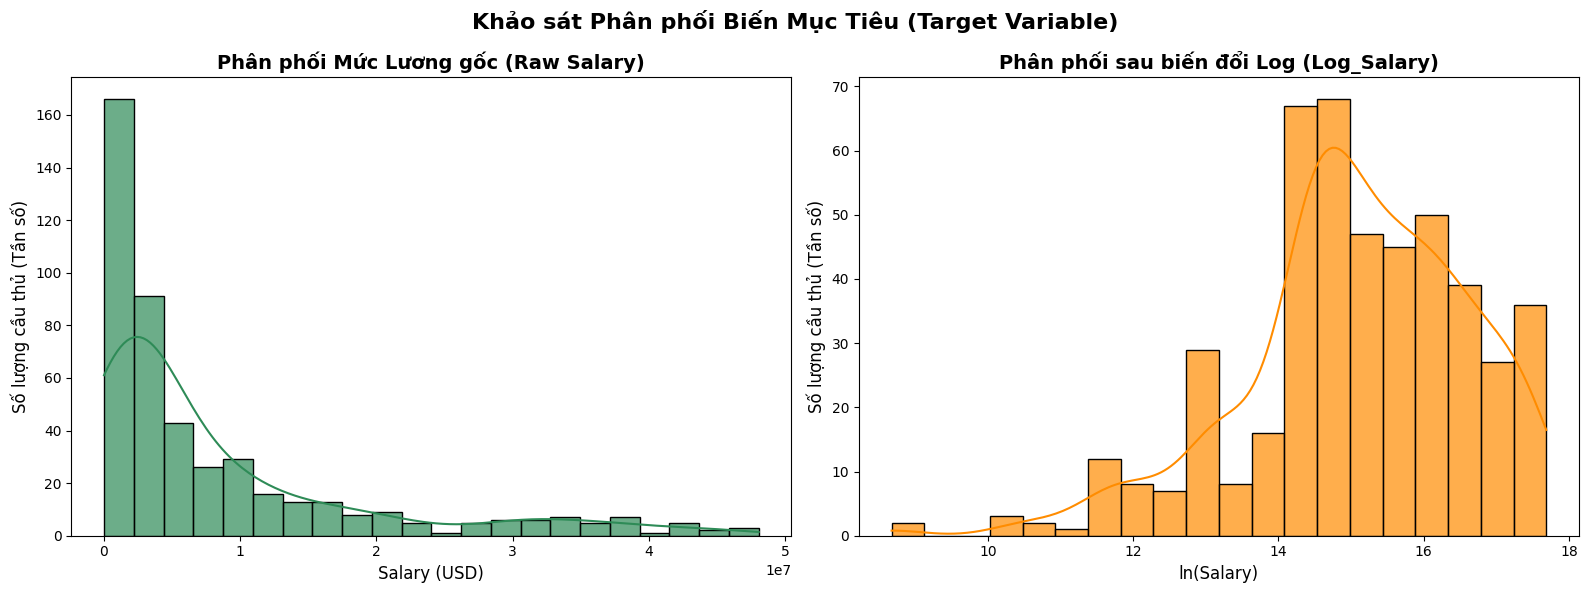

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Khảo sát Phân phối Biến Mục Tiêu (Target Variable)', fontsize=16, fontweight='bold')
sns.histplot(df['Salary'], kde=True, ax=axes[0], color='seagreen', edgecolor='black', alpha=0.7)
axes[0].set_title('Phân phối Mức Lương gốc (Raw Salary)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Salary (USD)', fontsize=12)
axes[0].set_ylabel('Số lượng cầu thủ (Tần số)', fontsize=12)

valid_salary = df[df['Salary'] > 0]['Salary']
log_salary = np.log(valid_salary)

sns.histplot(log_salary, kde=True, ax=axes[1], color='darkorange', edgecolor='black', alpha=0.7)
axes[1].set_title('Phân phối sau biến đổi Log (Log_Salary)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('ln(Salary)', fontsize=12)
axes[1].set_ylabel('Số lượng cầu thủ (Tần số)', fontsize=12)

plt.tight_layout()
plt.show()

Từ dữ liệu, có thể thấy: Khi lấy Logarit cho dữ liệu của biến Salary, dữ liệu gần về phân phối chuẩn hơn; ngoài ra con giúp ổn định phương sai, giảm thiểu khoảng cách của các điểm ngoại lai với phần còn lại.

- Đối với các biến khác

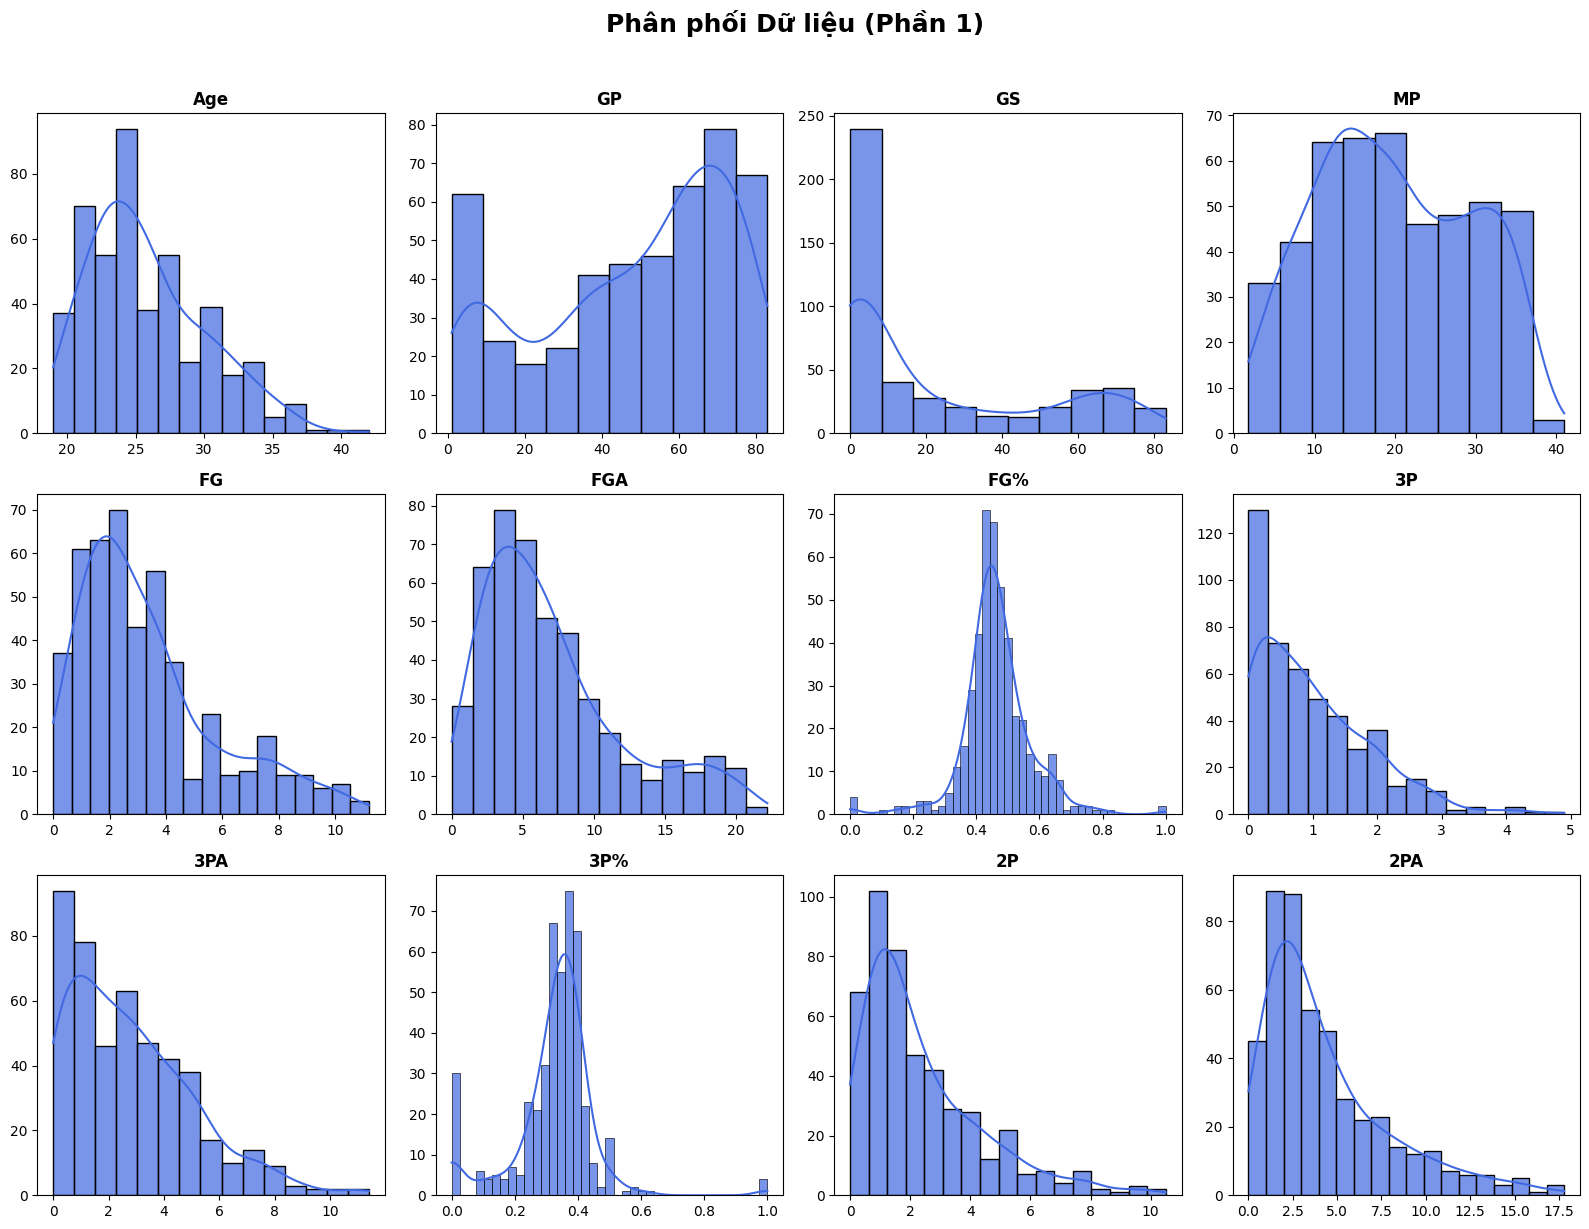

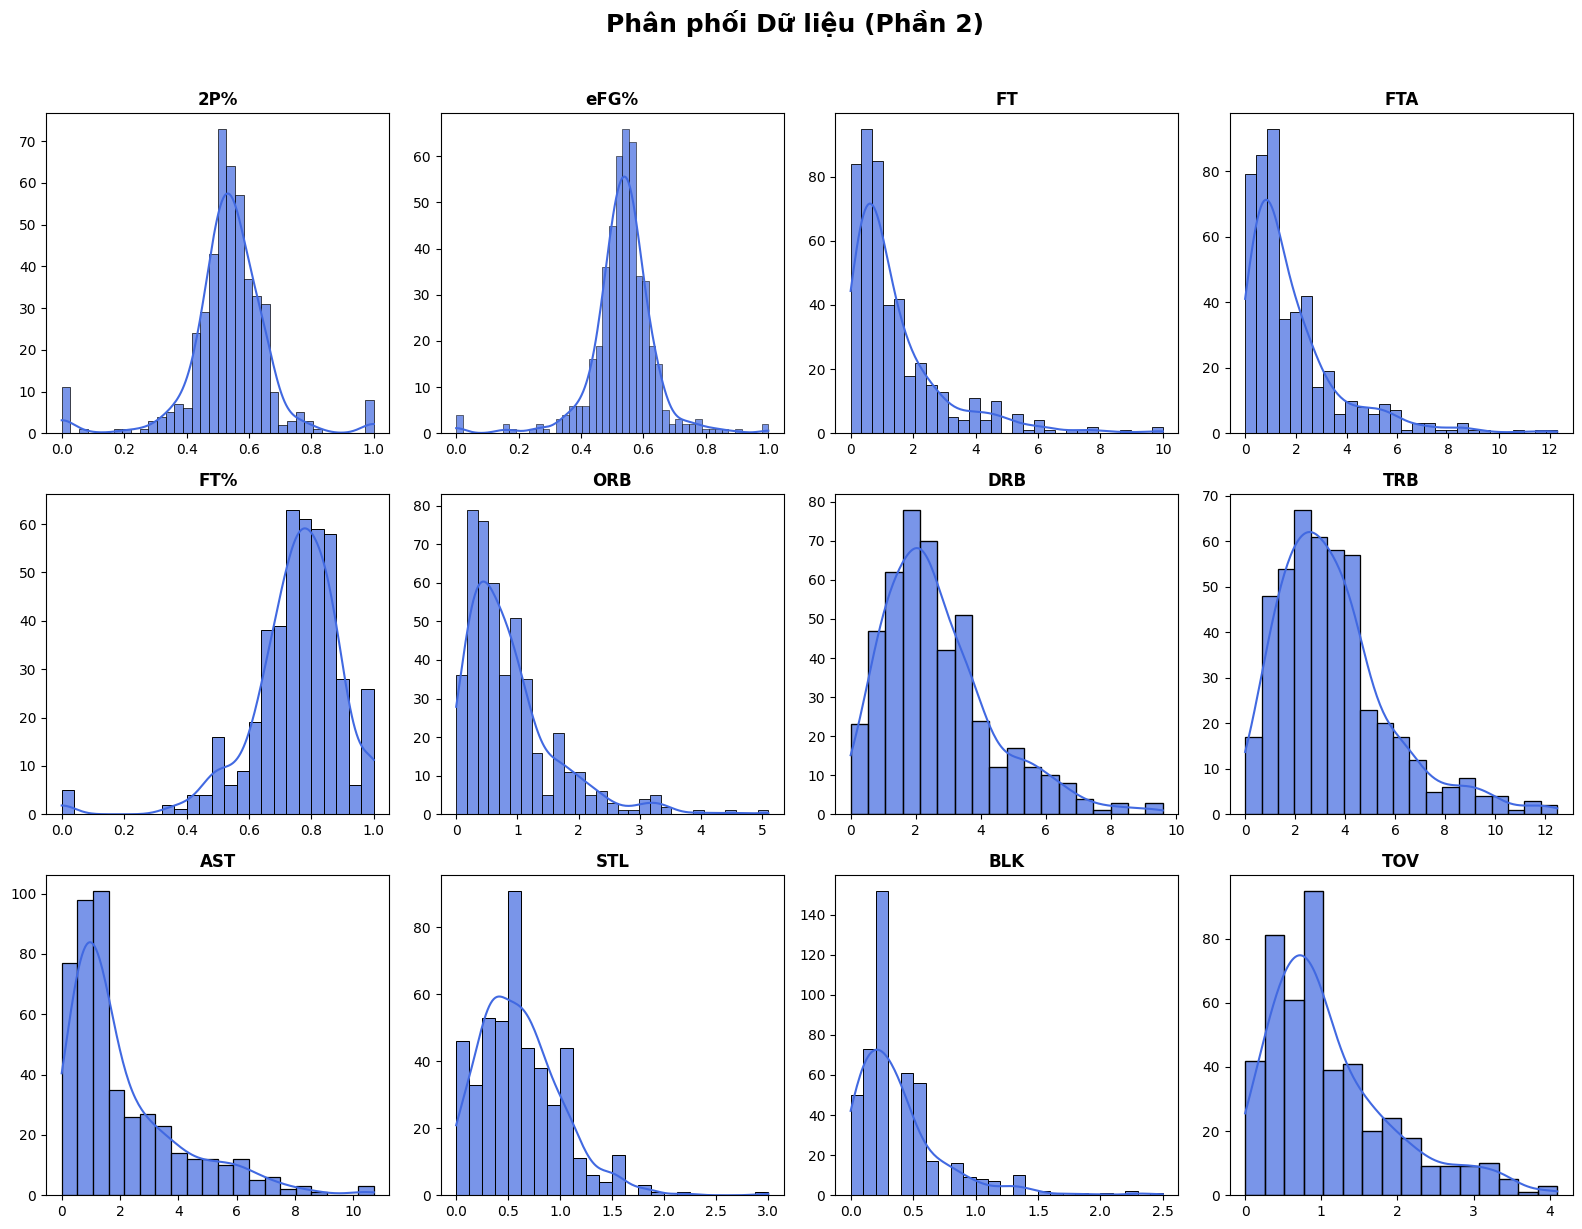

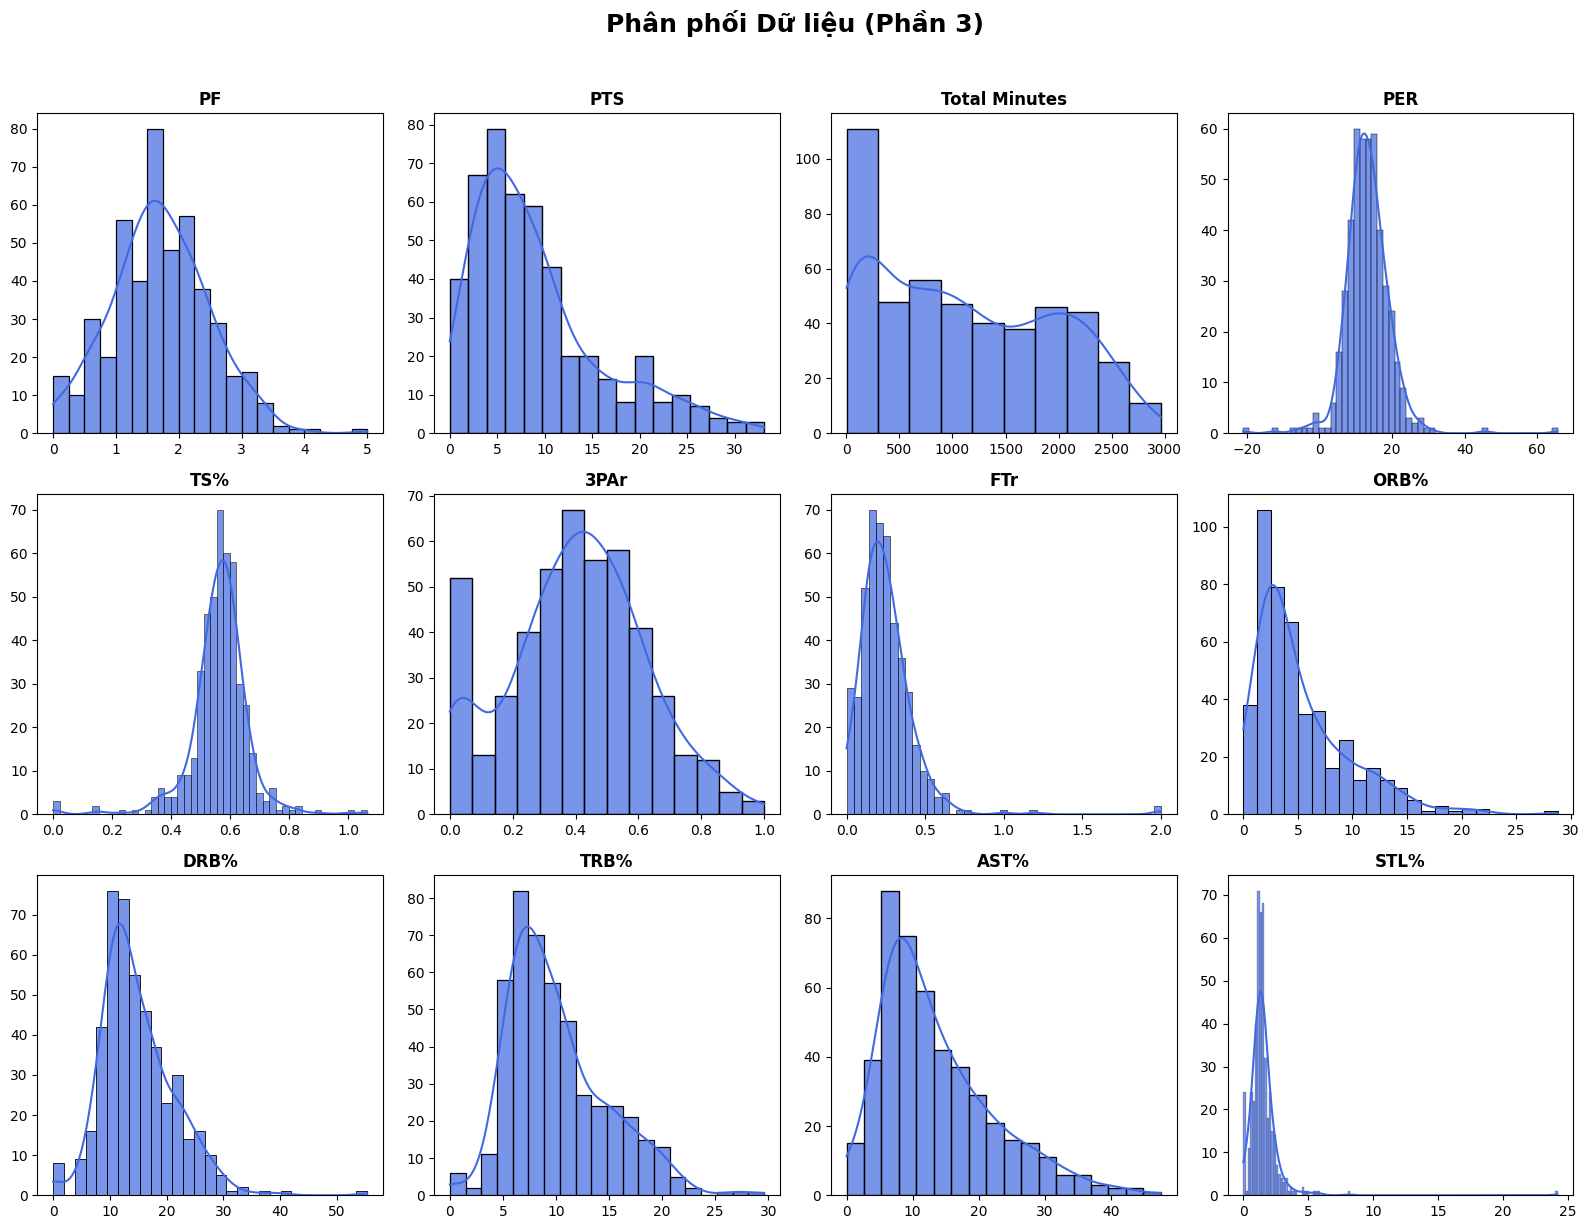

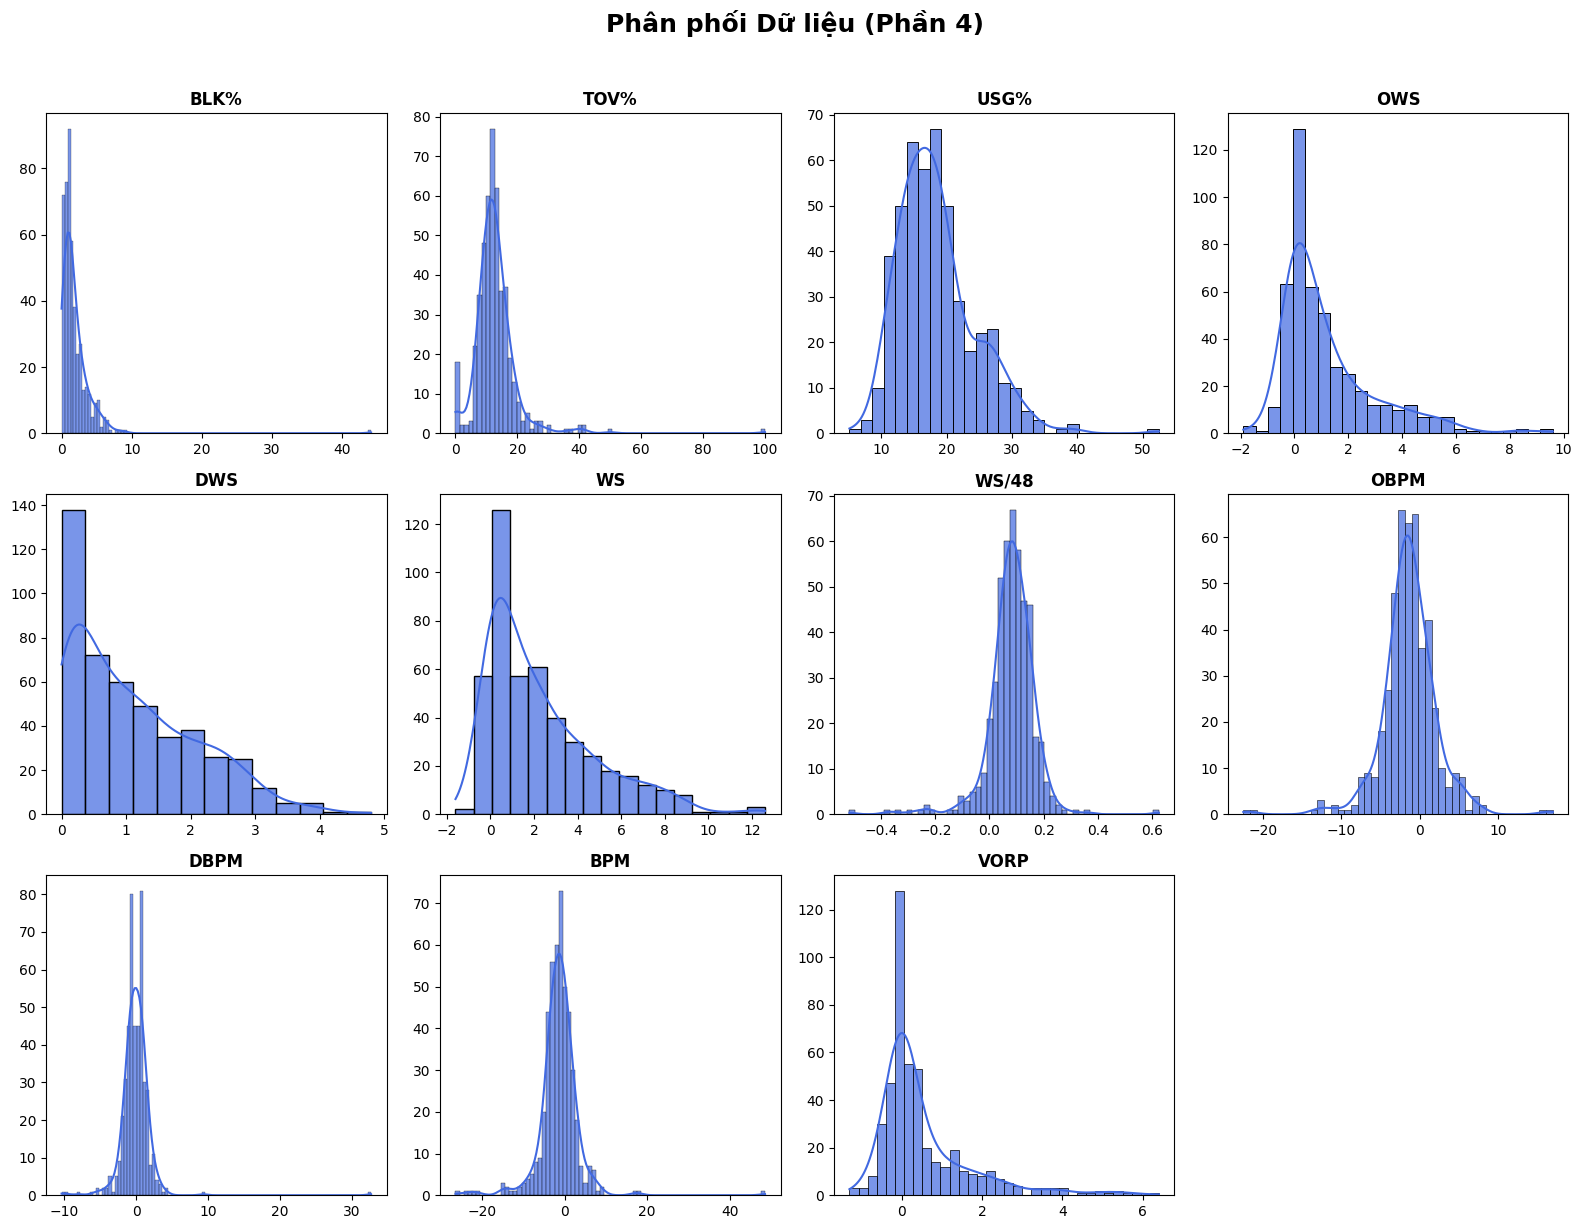

In [9]:
def plot_feature_cluster(df, features, title):
    """Vẽ lưới các Histogram cho một nhóm đặc trưng cụ thể"""
    if not features: return
    
    n_cols = 4
    n_rows = math.ceil(len(features) / n_cols)
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4 * n_rows))
    fig.suptitle(title, fontsize=18, fontweight='bold', y=1.02)
    
    # Ép axes về mảng 1 chiều để dễ lặp, đề phòng trường hợp chỉ có 1 hàng
    axes = np.array(axes).flatten()
    
    for i, col in enumerate(features):
        sns.histplot(df[col], kde=True, ax=axes[i], color='royalblue', edgecolor='black', alpha=0.7)
        axes[i].set_title(col, fontsize=12, fontweight='bold')
        axes[i].set_ylabel('')
        axes[i].set_xlabel('')
    
    # Ẩn các khung đồ thị bị dư (nếu số cột không chia hết cho 4)
    for j in range(len(features), len(axes)):
        fig.delaxes(axes[j])
        
    plt.tight_layout()
    plt.show()

exclude_cols = ['Unnamed: 0', 'PERSON_ID', 'TEAM_ID', 'Player', 'Salary', 'Log_Salary']
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
valid_features = [c for c in numeric_cols if c not in exclude_cols]

# Bước 3.2: Chia nhóm các cột để vẽ Histogram cho đỡ rối (Bạn có thể tinh chỉnh lại danh sách này)
# Tự động cắt danh sách valid_features thành các cụm 12 cột
chunk_size = 12
feature_chunks = [valid_features[i:i + chunk_size] for i in range(0, len(valid_features), chunk_size)]

# Vẽ các cụm Histogram
for idx, chunk in enumerate(feature_chunks):
    plot_feature_cluster(df, chunk, f"Phân phối Dữ liệu (Phần {idx + 1})")

- Boxplot để kiểm tra ngoại lai

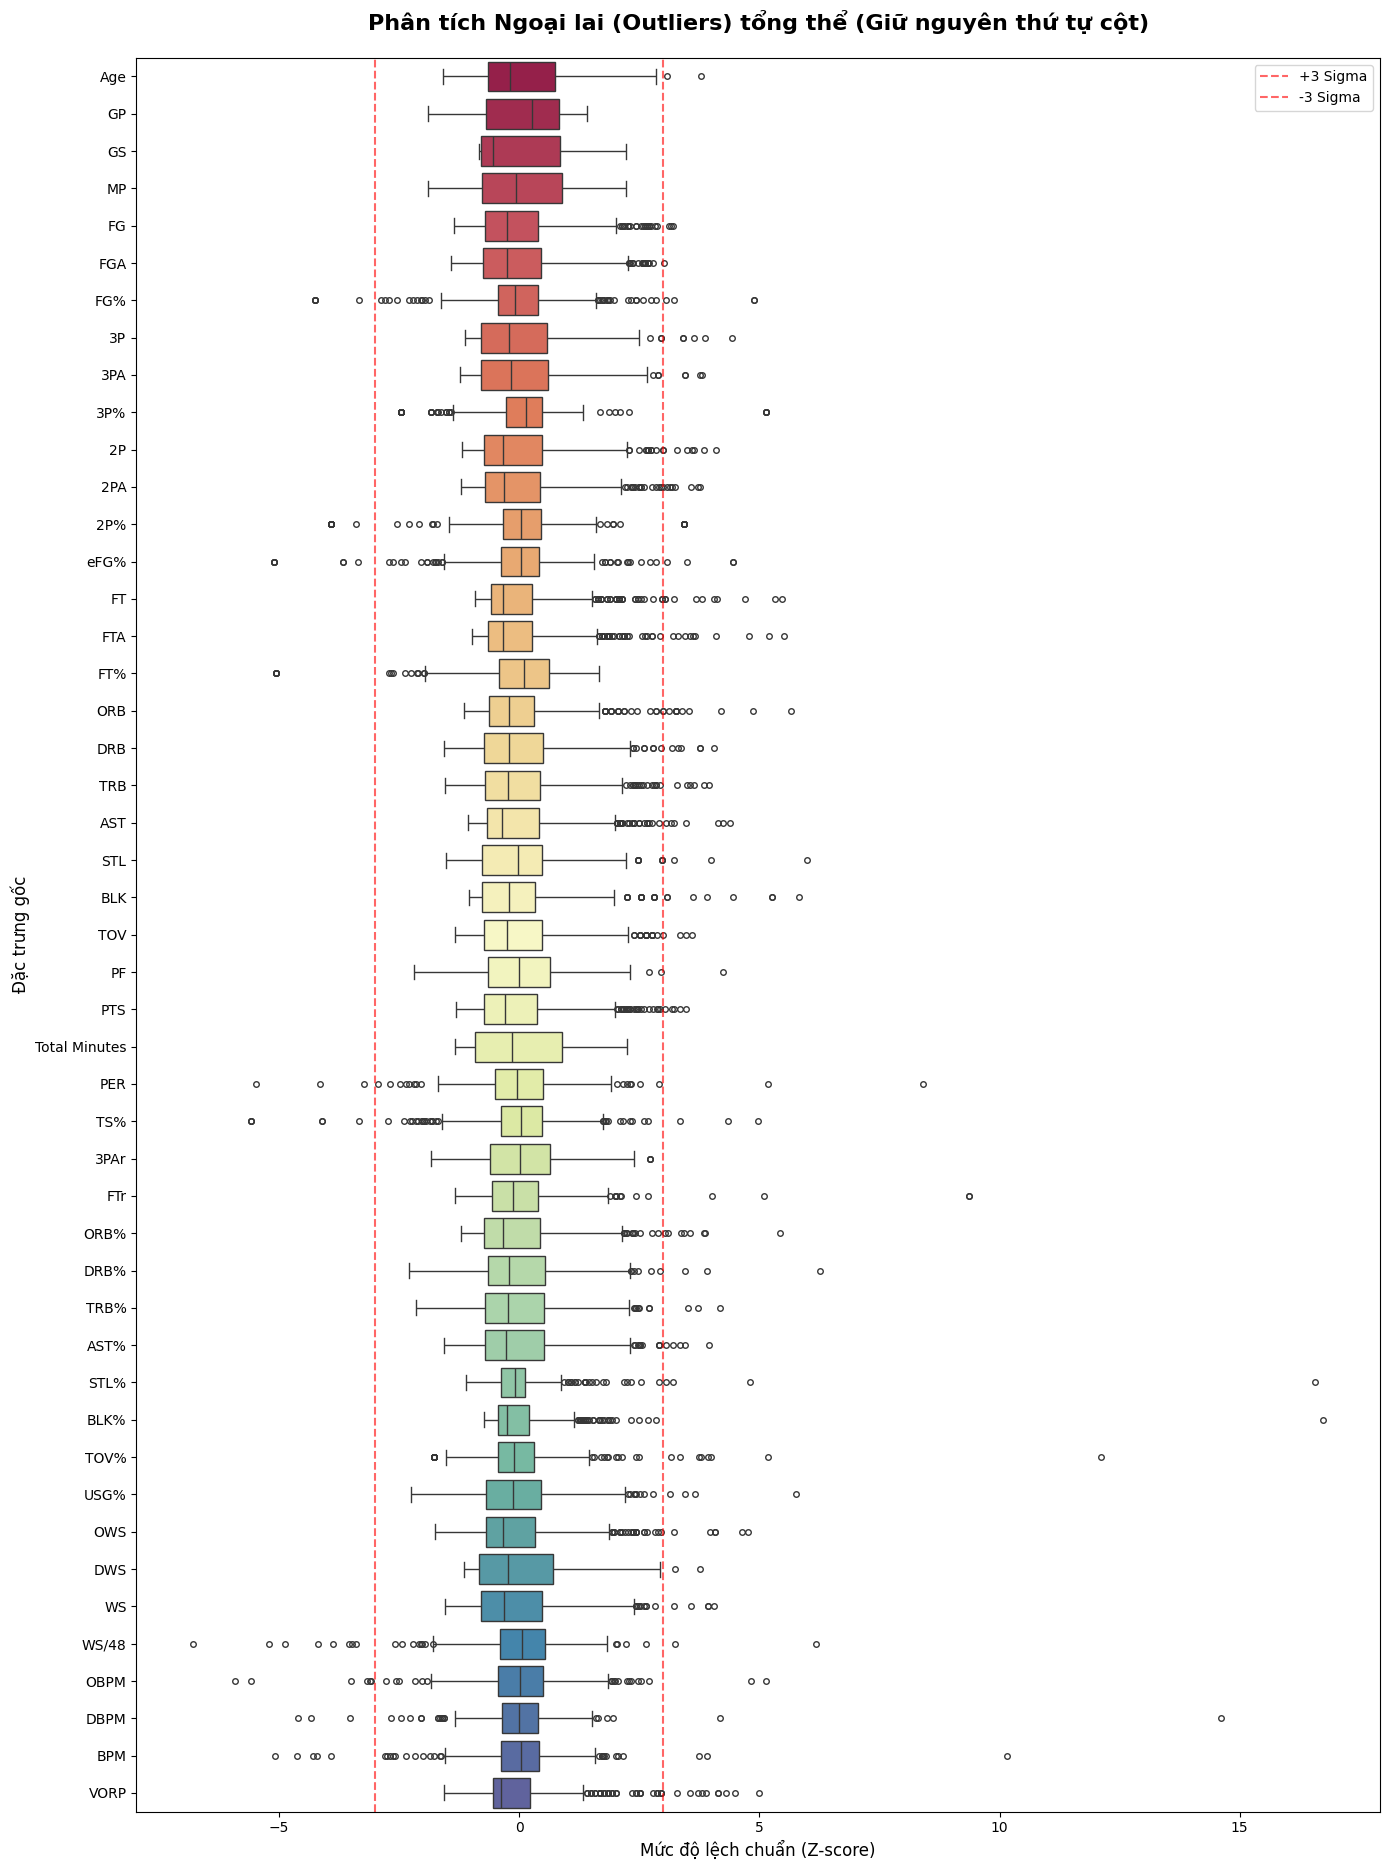

In [10]:
"""Vẽ Boxplot tổng thể bằng Z-score theo đúng thứ tự cột gốc"""

features = valid_features
    
# 1. Trích xuất dữ liệu và tính Z-score (bỏ qua NaN tự động)
numeric_df = df[features]
scaled_df = (numeric_df - numeric_df.mean()) / numeric_df.std()
    
# 2. Thiết lập kích thước khung hình linh hoạt theo số lượng biến
plt.figure(figsize=(14, max(8, len(features) * 0.4)))
    
# 3. Vẽ Boxplot
sns.boxplot(data=scaled_df, orient='h', palette='Spectral', fliersize=4)
    
# 4. Trang trí biểu đồ
plt.title("Phân tích Ngoại lai (Outliers) tổng thể (Giữ nguyên thứ tự cột)", 
    fontsize=16, fontweight='bold', pad=20)
plt.xlabel("Mức độ lệch chuẩn (Z-score)", fontsize=12)
plt.ylabel("Đặc trưng gốc", fontsize=12)
    
# 5. Vẽ 2 đường biên 3-sigma để làm mốc cảnh báo Outlier cực đoan
plt.axvline(x=3, color='red', linestyle='--', alpha=0.6, label='+3 Sigma')
plt.axvline(x=-3, color='red', linestyle='--', alpha=0.6, label='-3 Sigma')
plt.legend()
    
plt.tight_layout()
plt.show()

### 1.3. Ma trận tương quan (Correlation Heatmap)
Kiểm tra mức độ tương quan giữa các biến với nhau để xem biến nào ảnh hưởng mạnh đến Lương (Salary) và phát hiện đa cộng tuyến (Multicollinearity).

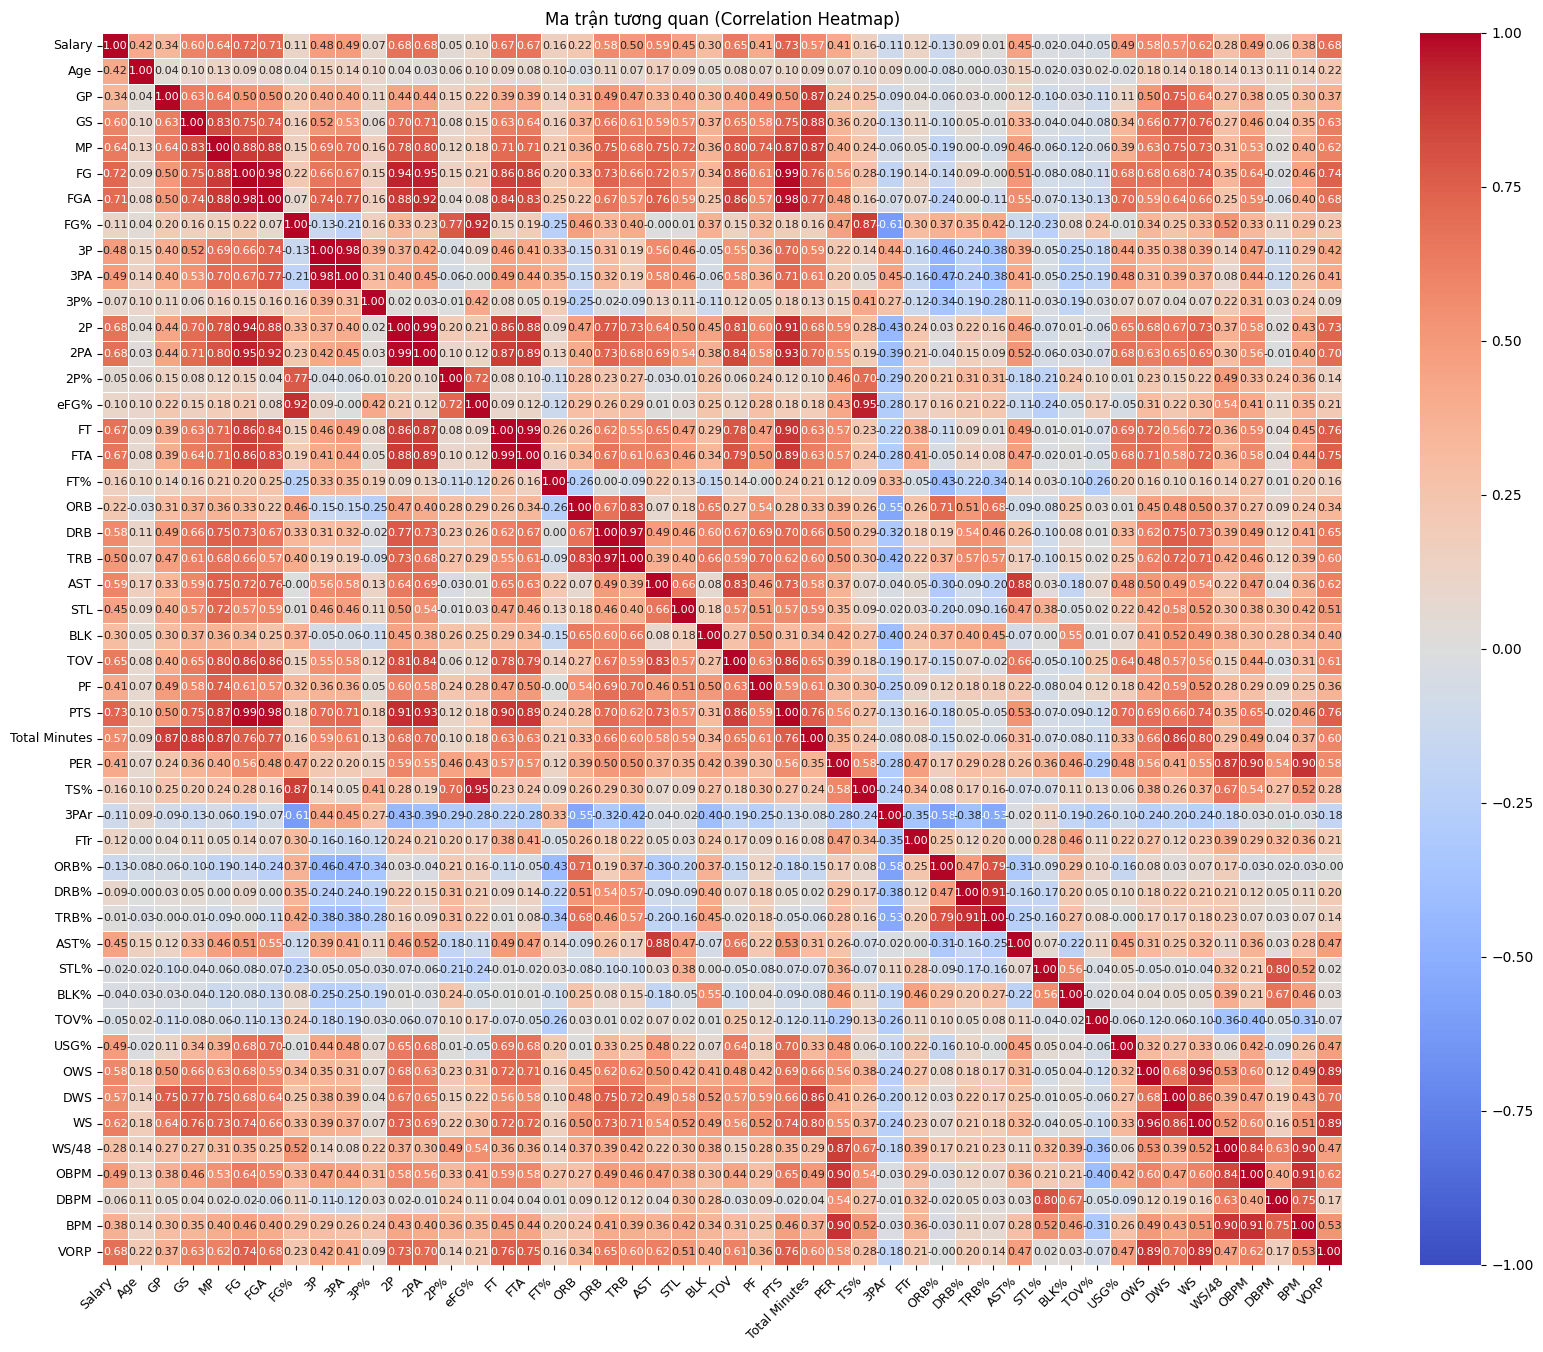

In [11]:
plt.figure(figsize=(20, 16))
# Tính ma trận tương quan (Pearson) cho các cột số
df = df.drop(columns=['Unnamed: 0'], errors='ignore')
corr_matrix = df.select_dtypes(include=['float64', 'int64']).corr()

# Vẽ Heatmap
sns.heatmap(corr_matrix, annot=True, annot_kws={'size': 8}, cmap='coolwarm', fmt=".2f", linewidths=0.5, vmin=-1, vmax=1)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(fontsize=9)
plt.title('Ma trận tương quan (Correlation Heatmap)')
plt.show()

## **2. Tiền xử lý dữ liệu (OOP Data Pipeline)**

Chúng ta chạy class `NBADataPipeline` thiết kế từ `part2/data_pipeline.py`. Quy trình tiền xử lý tuân thủ:
1. Chia Train/Test riêng biệt trước để chống rò rỉ dữ liệu (Data Leakage).
2. Chuẩn hóa đặc trưng số (Standardization) dựa trên thông số từ tập Train.
3. Điền khuyết bằng thuật toán K-NN (KNN Imputer) trên thang đo chuẩn hóa để tính khoảng cách chính xác.
4. Encode biến phân loại (Dummy Variables) và căn chỉnh tập Test trùng khớp tập Train.





- Chia Train/Test

In [12]:
from part2.data_pipeline import NBADataPipeline

train_df = df.sample(frac=0.8, random_state=42)
test_df = df.drop(train_df.index)
print(f"Kích thước Train: {train_df.shape[0]} dòng, {train_df.shape[1]} cột | Kích thước Test: {test_df.shape[0]} dòng, {train_df.shape[1]} cột")
print(f"Thống kê số ô bị khuyết trong tập Train ban đầu:")
print(train_df.isna().sum().sort_values(ascending=False).head(5))

Kích thước Train: 374 dòng, 51 cột | Kích thước Test: 93 dòng, 51 cột
Thống kê số ô bị khuyết trong tập Train ban đầu:
FT%     20
3P%     11
2P%      2
eFG%     1
FTr      1
dtype: int64


-  Fit trên tập Train

In [13]:
pipeline = NBADataPipeline()

pipeline.fit(train_df)
print("Pipeline đã học thành công các trạng thái (State):")
print(f" 1. Tham số chuẩn hóa Z-Score của cột PTS_per36 (Points): Mu = {pipeline.scaler_params['PTS_per36']['mu']:.2f}, Sigma = {pipeline.scaler_params['PTS_per36']['sigma']:.2f}")
print(f" 2. Các cột Dummy phân loại đã học: {len(pipeline.encoded_columns)} cột (VD: {pipeline.encoded_columns[:3]}...)")

Đang chạy VIF thuần Python để lọc đa cộng tuyến...
Pipeline đã học thành công các trạng thái (State):
 1. Tham số chuẩn hóa Z-Score của cột PTS_per36 (Points): Mu = 15.39, Sigma = 5.74
 2. Các cột Dummy phân loại đã học: 73 cột (VD: ['Position_PF', 'Position_PG', 'Position_PG-SG']...)


- Transform

In [14]:
X_train_processed = pipeline.transform(train_df)
print("Dữ liệu Train sau xử lý (Sạch NaN, Chuẩn hóa, Đã Encode Dummy):")

display(X_train_processed.head(3))

print(f"Kiểm tra Missing Values còn tồn tại trong Train: {X_train_processed.isna().sum().sum()} lỗi.")

# Áp dụng lên tập Test
X_test_processed = pipeline.transform(test_df)

print("\ Dữ liệu Test sau xử lý:")

display(X_test_processed.head(3))

print(f"Kiểm tra Missing Values còn tồn tại trong Test: {X_test_processed.isna().sum().sum()} lỗi.")

# Đối chiếu số lượng cột cuối cùng
if X_train_processed.shape[1] == X_test_processed.shape[1]:
    print(f"Tập Train và Test đã đồng nhất kích thước với {X_train_processed.shape[1]} cột!")

Dữ liệu Train sau xử lý (Sạch NaN, Chuẩn hóa, Đã Encode Dummy):


,Age,GS,3P%,2P%,FT%,PF,FTr,is_rookie,Position_PF,Position_PG,...,Team_SAC,Team_SAS,Team_SAS/MIL,Team_SAS/PHI,Team_SAS/TOR,Team_TOR,Team_UTA,Team_WAS,Team_WAS/TOR,Log_Salary
55,0.984953,1.850014,0.730003,-0.121486,0.475627,0.384910,-0.705125,-0.728946,0,0,...,0,0,0,0,0,0,0,0,0,16.868462
63,0.750021,2.070098,0.320897,-0.272406,0.408608,0.895848,0.389077,-0.728946,0,0,...,0,0,0,0,0,0,0,0,0,16.785925
33,0.045227,1.666611,0.445090,0.240721,0.777212,1.023582,0.089611,-0.728946,0,0,...,0,0,0,0,0,0,0,0,0,17.246712


Kiểm tra Missing Values còn tồn tại trong Train: 0 lỗi.
\ Dữ liệu Test sau xử lý:


,Age,GS,3P%,2P%,FT%,PF,FTr,is_rookie,Position_PF,Position_PG,...,Team_SAC,Team_SAS,Team_SAS/MIL,Team_SAS/PHI,Team_SAS/TOR,Team_TOR,Team_UTA,Team_WAS,Team_WAS/TOR,Log_Salary
1,1.454815,-0.717625,-0.161263,-0.566699,-0.469341,0.001708,0.504257,-0.728946,0,1,...,0,0,0,0,0,0,0,0,0,17.672988
13,1.219884,-0.130736,-0.073598,-0.136578,1.011779,0.512645,0.026263,-0.728946,0,0,...,0,0,0,0,0,0,0,0,0,17.452683
20,0.045227,0.382792,-2.374818,0.278451,-2.091202,2.045456,-0.019809,-0.728946,0,1,...,0,0,0,0,0,0,0,0,0,17.383596


Kiểm tra Missing Values còn tồn tại trong Test: 0 lỗi.
Tập Train và Test đã đồng nhất kích thước với 82 cột!


### Khảo sát lại ma trận tương quan sau khi qua Pipeline
Chúng ta hãy vẽ lại Heatmap để kiểm chứng:

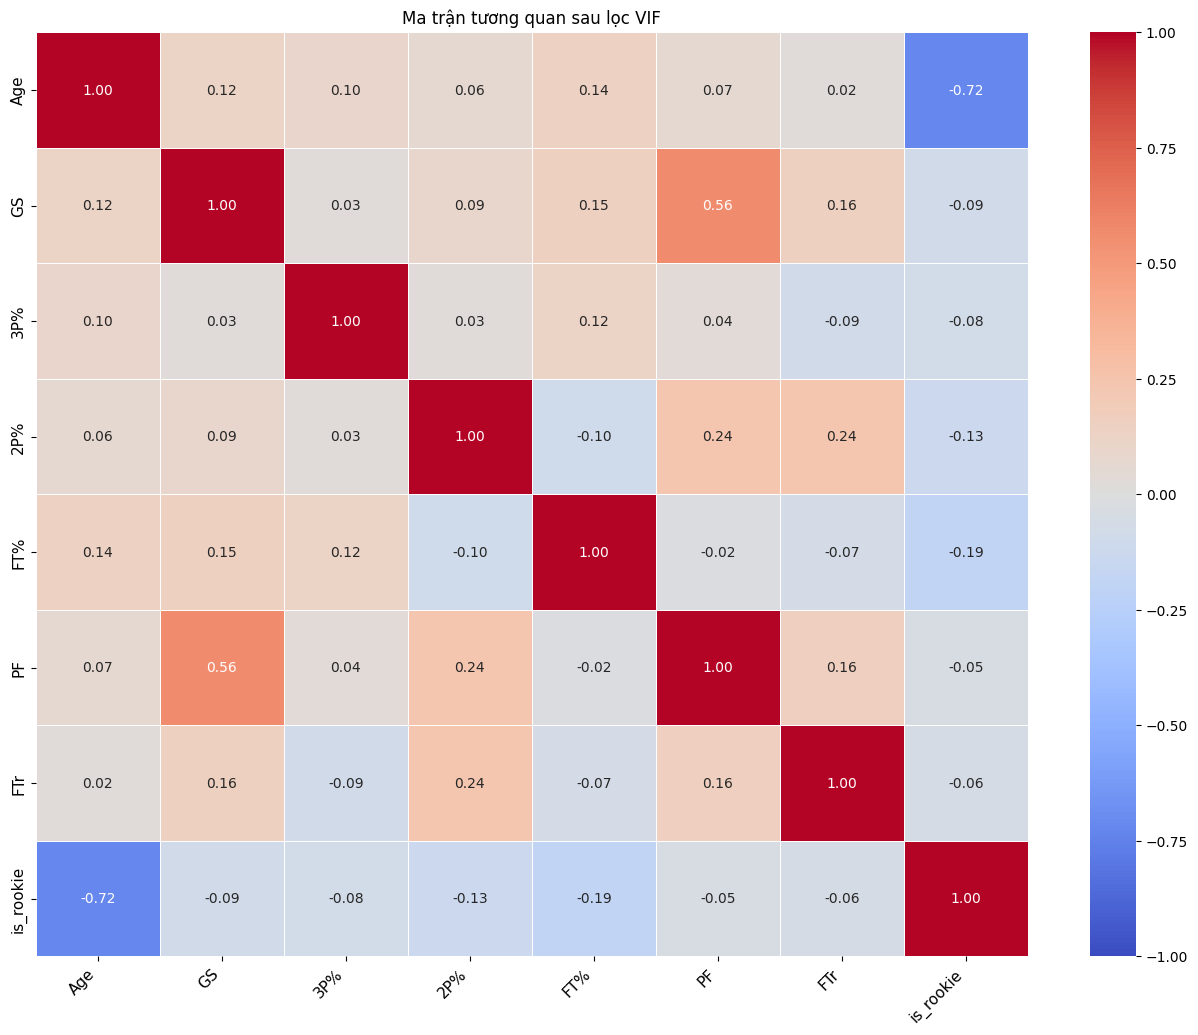

In [15]:
# Lọc ra các cột số (không tính cột phân loại - Dummy) trong X_train_processed để vẽ
numeric_cols_after = pipeline.vif_passed_features
corr_matrix_after = X_train_processed[numeric_cols_after].corr()

plt.figure(figsize=(16, 12))
sns.heatmap(corr_matrix_after, annot=True, annot_kws={'size': 10}, cmap='coolwarm', fmt=".2f", linewidths=0.5, vmin=-1, vmax=1)
plt.xticks(rotation=45, ha='right', fontsize=11)
plt.yticks(fontsize=11)
plt.title(f'Ma trận tương quan sau lọc VIF')
plt.show()

## **3. Huấn luyện và So sánh các mô hình**

Chúng ta sẽ thực thi toàn bộ script `part2/model_comparison.py` để:
- Huấn luyện 5 mô hình (OLS, OLS chọn biến, Ridge, Lasso, Bayesian)
- Đánh giá mô hình trên tập Test riêng biệt thông qua các chỉ số MAE, RMSE, R2 trên thang đo gốc (USD)
- Vẽ đồ thị phân tích chẩn đoán phần dư
- Vẽ đồ thị khoảng tin cậy Bayesian

Setup dữ liệu để các mô hình có thể dùng chung từ cell này

In [16]:
# Lấy dữ liệu mục tiêu và danh sách cột
y_test_raw = test_df["Salary"].tolist()
if "Log_Salary" in X_train_processed.columns:
    y_train = X_train_processed.pop("Log_Salary")
else:
    y_train = train_df["Log_Salary"]
if "Log_Salary" in X_test_processed.columns:
    X_test_processed.pop("Log_Salary")
feature_names = list(X_train_processed.columns)

# Chuyển đổi định dạng dữ liệu (bỏ qua thư viện NumPy)
X_train_arr = hf.as_2d_float_array(X_train_processed.values, "X_train")
y_train_arr = hf.as_1d_float_array(y_train.values, "y_train")
X_test_arr = hf.as_2d_float_array(X_test_processed.values, "X_test")

# Thêm cột Bias (Intercept)
X_train_bias = hf.column_stack([hf.ones(X_train_arr.shape[0])] + list(X_train_arr.T))
X_test_bias = hf.column_stack([hf.ones(X_test_arr.shape[0])] + list(X_test_arr.T))

print("Đã setup và chuẩn bị xong dữ liệu cho các mô hình!")


Đã setup và chuẩn bị xong dữ liệu cho các mô hình!


### 3.1. Mô hình OLS cơ bản


Huấn luyện Model 1: OLS Cơ Bản...
MAE  : 6,086,465.77 USD
RMSE : 13,875,766.77 USD
R2   : -1.0392


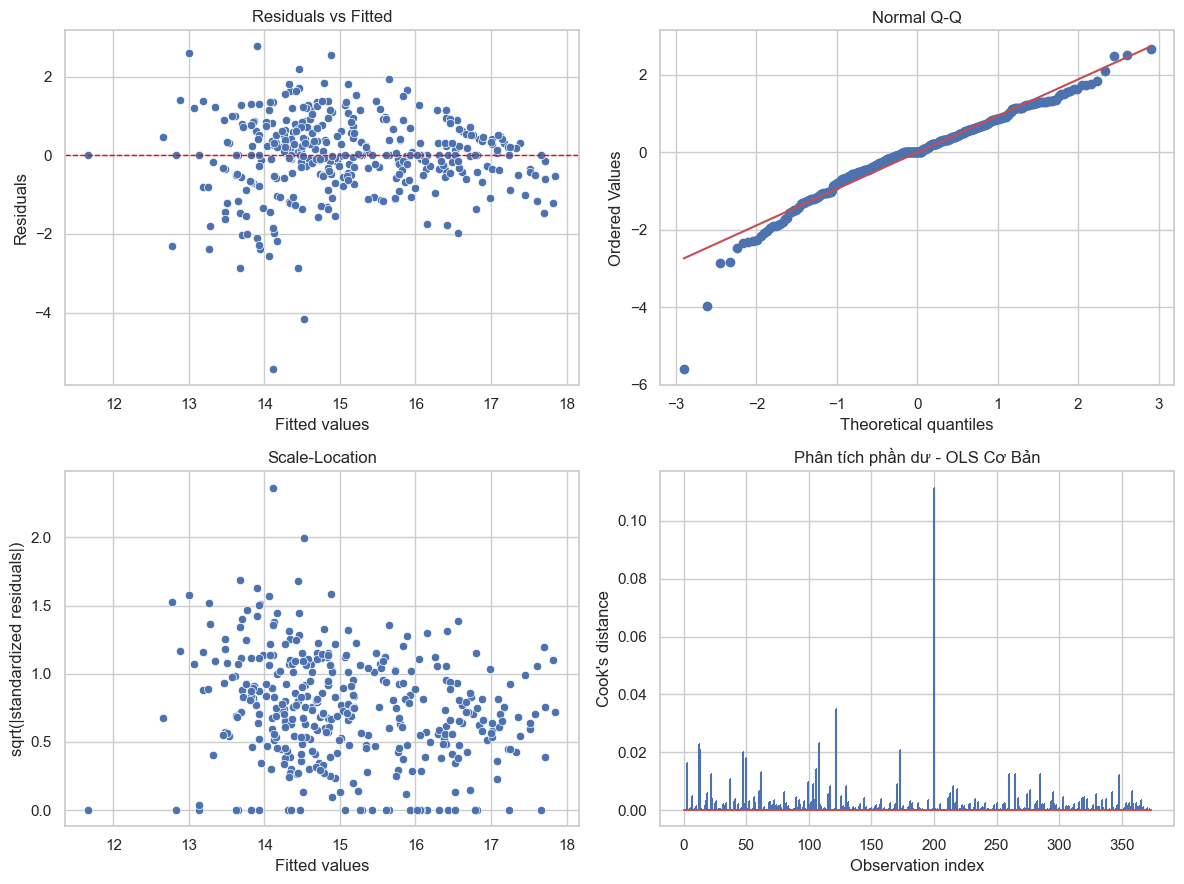

In [17]:
# Import hàm từ file đã refactor
from part2.model_comparison import run_ols_basic
# 1. Gọi hàm thực thi OLS Cơ Bản
results_ols, beta_ols, sigma2_ols = run_ols_basic(
    X_train_bias, y_train_arr, X_test_bias, y_test_raw
)

# 2. Hiển thị kết quả
print(f"MAE  : {results_ols['MAE']:,.2f} USD")
print(f"RMSE : {results_ols['RMSE']:,.2f} USD")
print(f"R2   : {results_ols['R2']:.4f}")

# 3. Vẽ đồ thị chẩn đoán phần dư
fig = residual_plots(X_train_bias, y_train_arr, beta_ols)
plt.title("Phân tích phần dư - OLS Cơ Bản")
plt.show()


### 3.2. Mô hình OLS chọn biến


Huấn luyện Model 2: OLS Chọn Biến...
  - VIF lọc giảm số lượng đặc trưng từ 81 xuống 81
  - p-value lọc giảm tiếp số lượng đặc trưng xuống 3: ['Age', 'GS', 'PF']
Đặc trưng giữ lại: 3
MAE  : 4,404,517.21 USD
RMSE : 8,311,748.61 USD
R2   : 0.2683


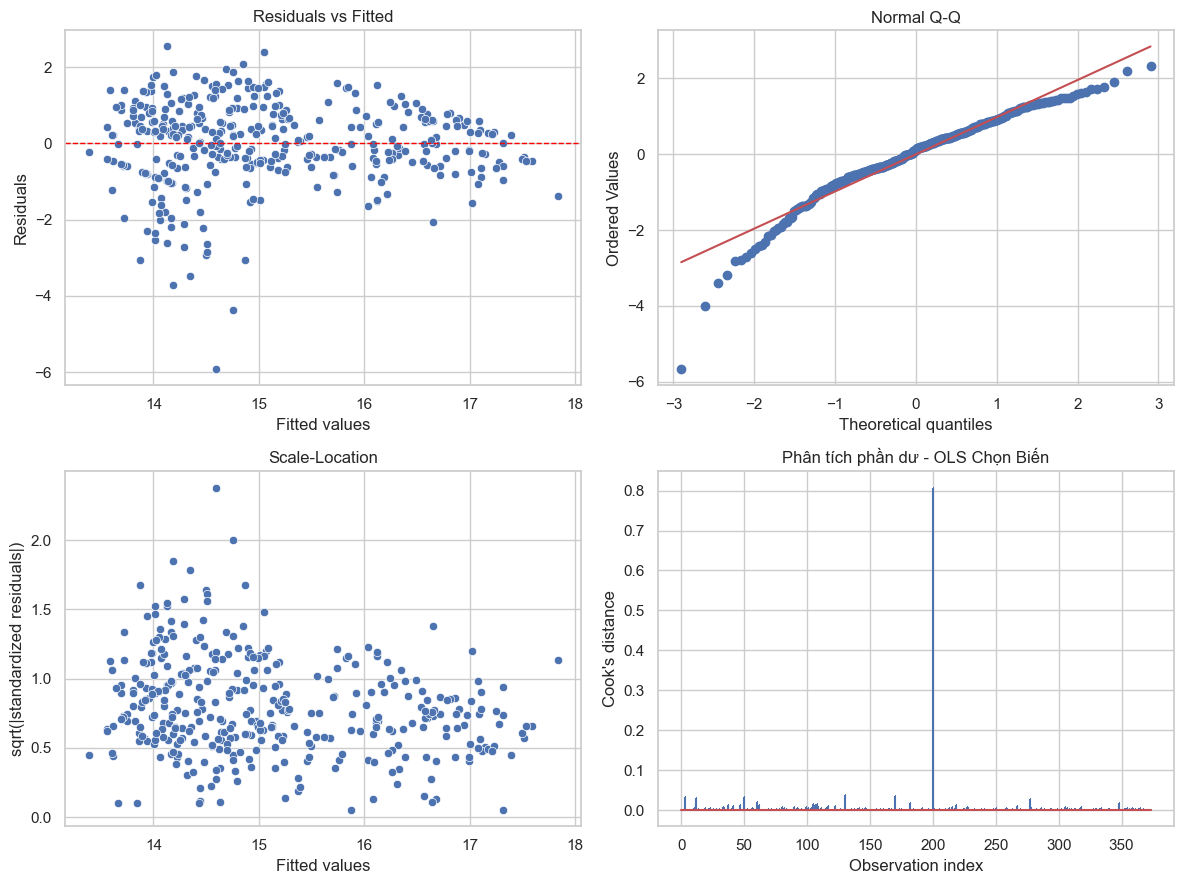

In [18]:
from part2.model_comparison import run_ols_selected

# 1. Gọi hàm thực thi OLS Chọn biến
results_sel, beta_sel, sigma2_sel, X_train_final_bias = run_ols_selected(
    X_train_arr, y_train_arr, X_test_arr, feature_names, y_test_raw, X_train_processed, X_test_processed
)

# 2. Hiển thị kết quả
print(f"Đặc trưng giữ lại: {len(results_sel['features'])}")
print(f"MAE  : {results_sel['MAE']:,.2f} USD")
print(f"RMSE : {results_sel['RMSE']:,.2f} USD")
print(f"R2   : {results_sel['R2']:.4f}")

# 3. Phân tích phần dư
fig = residual_plots(X_train_final_bias, y_train_arr, beta_sel)
plt.title("Phân tích phần dư - OLS Chọn Biến")
plt.show()


### 3.3. Mô hình Ridge Regression


Huấn luyện Model 3: Ridge Regression...
✅ Đã lưu Ridge Trace tại: ridge_trace.png
  - Ridge: Lambda tối ưu chọn bởi 5-Fold CV: 1.0
Lambda Tối Ưu : 1.0
MAE           : 5,165,591.03 USD
RMSE          : 9,610,999.47 USD
R2            : 0.0217


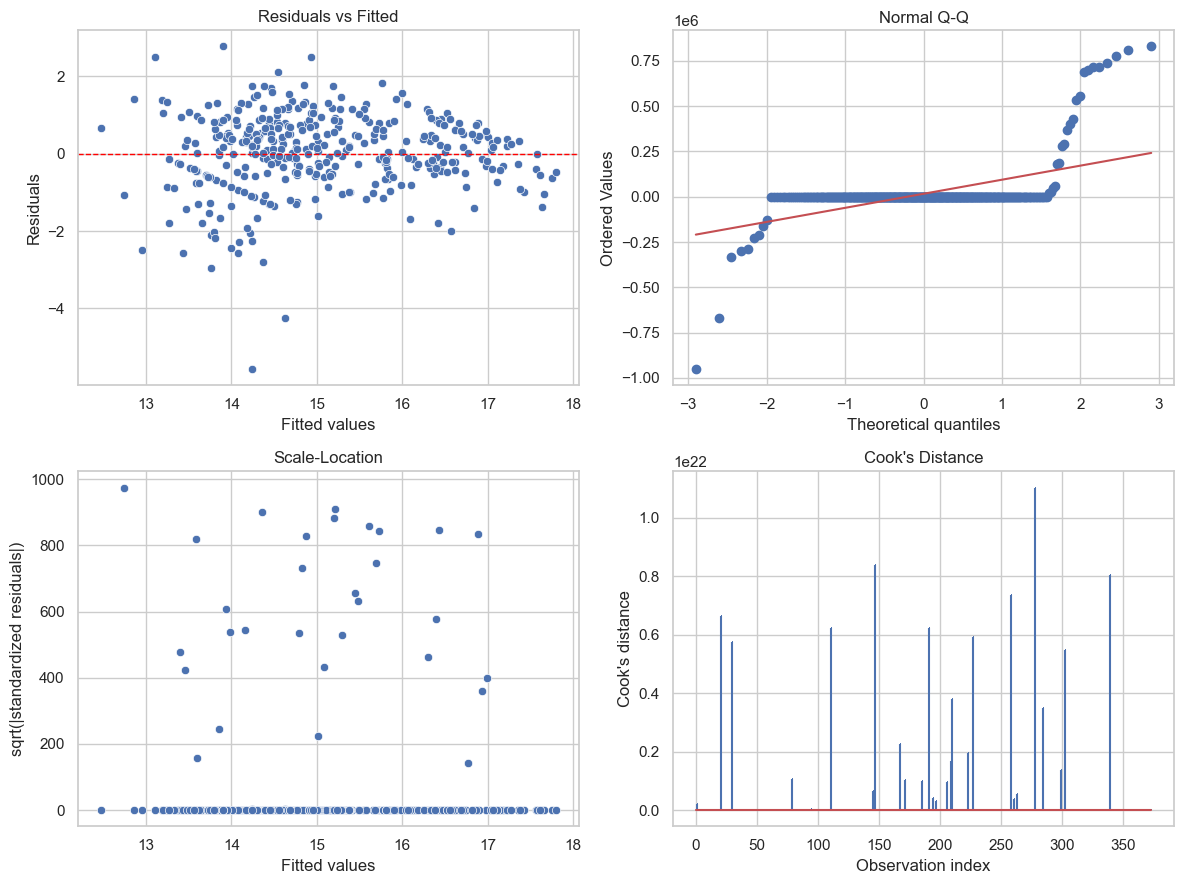

In [19]:
from part2.model_comparison import run_ridge_regression

# Gọi hàm thực thi Ridge
results_ridge, beta_ridge = run_ridge_regression(
    X_train_bias, y_train_arr, X_test_bias, y_test_raw
)

print(f"Lambda Tối Ưu : {results_ridge['best_lambda']}")
print(f"MAE           : {results_ridge['MAE']:,.2f} USD")
print(f"RMSE          : {results_ridge['RMSE']:,.2f} USD")
print(f"R2            : {results_ridge['R2']:.4f}")

fig_ridge = residual_plots(X_train_bias, y_train_arr, beta_ridge)
plt.show()


### 3.4. Mô hình Lasso Regression

In [ ]:
from part2.model_comparison import run_lasso_regression

# Gọi hàm thực thi Lasso
results_lasso, beta_lasso = run_lasso_regression(
    X_train_bias, y_train_arr, X_test_bias, y_test_raw
)

print(f"Lambda Tối Ưu : {results_lasso['best_lambda']}")
print(f"MAE           : {results_lasso['MAE']:,.2f} USD")
print(f"RMSE          : {results_lasso['RMSE']:,.2f} USD")
print(f"R2            : {results_lasso['R2']:.4f}")

fig = residual_plots(X_train_final_bias, y_train_arr, beta_sel)
plt.show()




Huấn luyện Model 4: Lasso Regression...
  - Lasso: Lambda tối ưu chọn bởi 5-Fold CV: 1.0
  - Debug Lasso: Model đã tự động thu gọn (shrink) 36 / 81 đặc trưng về 0.
Lambda Tối Ưu : 1.0
MAE           : 4,969,900.86 USD
RMSE          : 9,099,584.87 USD
R2            : 0.1230


### 3.5. Mô hình Bayesian Linear Regression


Huấn luyện Model 5: Bayesian Linear Regression...
  - Debug Bayesian: Tính toán Posterior Mean (mu_N) và Covariance (Sigma_N) với kích thước (82, 82).
  - Debug Bayesian: Phương sai hậu nghiệm trung bình của các hệ số (độ bất định): 2.7124e-01
MAE  : 5,165,591.03 USD
RMSE : 9,610,999.47 USD
R2   : 0.0217


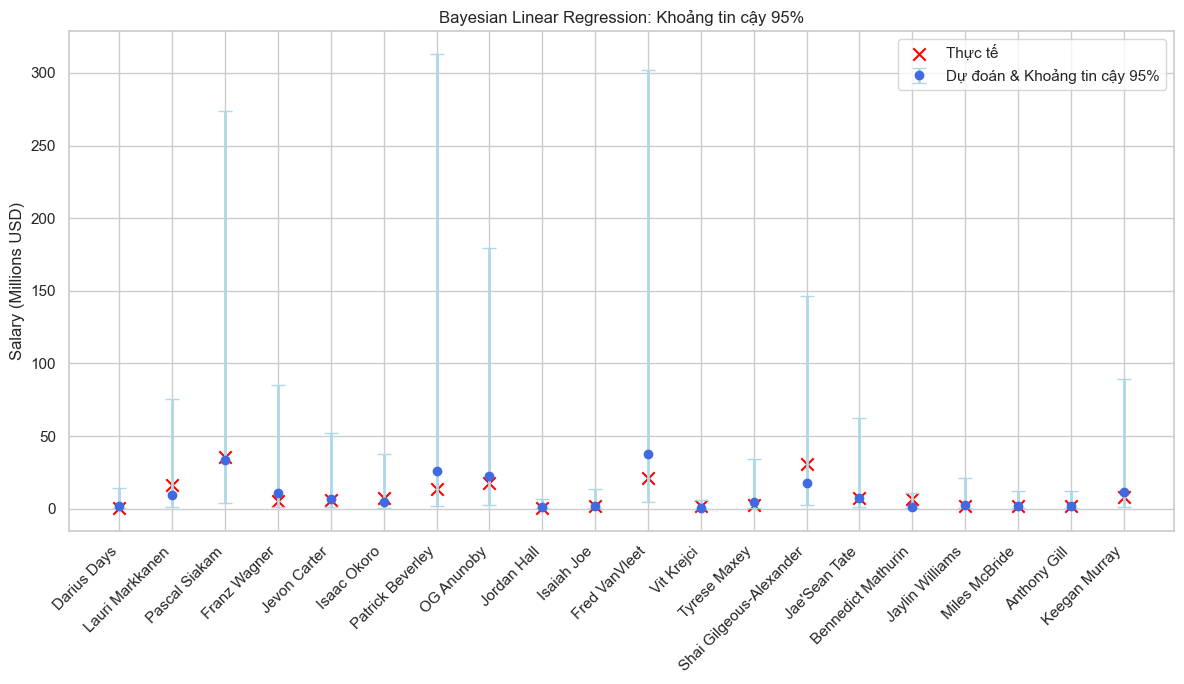

In [21]:
from part2.model_comparison import run_bayesian_regression
import random
# 1. Gọi hàm thực thi Bayesian
results_bayes, bayesian_model = run_bayesian_regression(
    X_train_bias, y_train_arr, X_test_bias, y_test_raw
)

print(f"MAE  : {results_bayes['MAE']:,.2f} USD")
print(f"RMSE : {results_bayes['RMSE']:,.2f} USD")
print(f"R2   : {results_bayes['R2']:.4f}")

# 2. Trực quan hóa khoảng tin cậy 95%
random.seed(42)
sample_indices = random.sample(range(len(y_test_raw)), 20)
y_test_sample_raw = [y_test_raw[i] for i in sample_indices]
X_test_sample_bias = hf.Matrix([X_test_bias[i] for i in sample_indices])
player_names = [test_df.iloc[i]["Player Name"] for i in sample_indices]

lower_log, upper_log = bayesian_model.get_credible_intervals(X_test_sample_bias, confidence=0.95)
y_pred_sample_log = bayesian_model.predict(X_test_sample_bias)

y_pred_sample_raw = [math.exp(val) for val in y_pred_sample_log]
lower_raw = [math.exp(val) for val in lower_log]
upper_raw = [math.exp(val) for val in upper_log]

plt.figure(figsize=(12, 7))
x_axis = range(20)
yerr_lower = [(pred - low) / 1e6 for pred, low in zip(y_pred_sample_raw, lower_raw)]
yerr_upper = [(up - pred) / 1e6 for pred, up in zip(y_pred_sample_raw, upper_raw)]

plt.errorbar(
    x_axis, [val / 1e6 for val in y_pred_sample_raw], yerr=[yerr_lower, yerr_upper],
    fmt="o", color="royalblue", ecolor="lightblue", capsize=5, elinewidth=2,
    label="Dự đoán & Khoảng tin cậy 95%",
)
plt.scatter(
    x_axis, [val / 1e6 for val in y_test_sample_raw], color="red", marker="x", s=80, label="Thực tế"
)
plt.xticks(x_axis, player_names, rotation=45, ha="right")
plt.ylabel("Salary (Millions USD)")
plt.title("Bayesian Linear Regression: Khoảng tin cậy 95%")
plt.legend()
plt.tight_layout()
plt.show()


### 3.6. Mô hình Polynomial Regression

In [22]:
from part2.model_comparison import run_polynomial_regression

# 1. Gọi hàm thực thi Polynomial Regression
# (Chú ý: Đã thay biến degree bằng feature_names để model tự động nhận diện cột)
results_poly, beta_poly, X_train_poly_bias = run_polynomial_regression(
    X_train_arr, y_train_arr, X_test_arr, y_test_raw, feature_names
)

# 2. Hiển thị kết quả
print(f"Lambda Tối Ưu : {results_poly['best_lambda']}")
print(f"MAE           : {results_poly['MAE']:,.2f} USD")
print(f"RMSE          : {results_poly['RMSE']:,.2f} USD")
print(f"R2            : {results_poly['R2']:.4f}")

# 3. Phân tích phần dư (Tuỳ chọn)
fig = residual_plots(X_train_poly_bias, y_train_arr, beta_poly)
plt.title("Phân tích phần dư - Polynomial Regression")
plt.show()



Huấn luyện Model 6: Polynomial Regression (Ridge trên biến liên tục)...


KeyboardInterrupt: 

### So sánh MAE, RMSE, R_Square của từng mô hình

In [ ]:
# Gom tất cả kết quả từ các cell trước đó
all_results = {
    "OLS Cơ Bản": results_ols,
    "OLS Chọn Biến": results_sel,
    "Ridge Regression": results_ridge,
    "Lasso Regression": results_lasso,
    "Bayesian Regression": results_bayes
}
comparison_rows = []
for model_name, metrics in all_results.items():
    
    # Xác định ghi chú (siêu tham số lambda hoặc số đặc trưng giữ lại)
    note = "Mặc định"
    if "best_lambda" in metrics:
        note = f"Lambda = {metrics['best_lambda']}"
    elif "features" in metrics:
        note = f"{len(metrics['features'])} đặc trưng"
    # Định dạng lại dữ liệu
    comparison_rows.append({
        "Mô hình": model_name,
        "MAE (USD)": f"{metrics['MAE']:,.2f}",
        "RMSE (USD)": f"{metrics['RMSE']:,.2f}",
        "R2 Score": f"{metrics['R2']:.4f}",
        "Ghi chú / Siêu tham số": note
    })
# Tạo DataFrame
comparison_df = pd.DataFrame(comparison_rows)
# Hiển thị bảng đẹp mắt bằng display() của Jupyter Notebook
print("=" * 80)
print("BẢNG TỔNG HỢP SO SÁNH CÁC MÔ HÌNH HỒI QUY (ĐÁNH GIÁ TRÊN TẬP TEST)")
print("=" * 80)
display(comparison_df)

BẢNG TỔNG HỢP SO SÁNH CÁC MÔ HÌNH HỒI QUY (ĐÁNH GIÁ TRÊN TẬP TEST)


,Mô hình,MAE (USD),RMSE (USD),R2 Score,Ghi chú / Siêu tham số
0,OLS Cơ Bản,"6,086,465.77","13,875,766.77",-1.0392,Mặc định
1,OLS Chọn Biến,"4,404,517.21","8,311,748.61",0.2683,3 đặc trưng
2,Ridge Regression,"5,165,591.03","9,610,999.47",0.0217,Lambda = 1.0
3,Lasso Regression,"4,969,900.86","9,099,584.87",0.1230,Lambda = 1.0
4,Bayesian Regression,"5,165,591.03","9,610,999.47",0.0217,Mặc định
